In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import warnings
warnings.filterwarnings('ignore')

c:\Users\LENOVO\Desktop\ecommerce-supply-chain-analytics\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [3]:
df = pd.read_csv('../data/raw/amazon_ecommerce_1M.csv')

In [4]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

In [5]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

For this project, I will focus on forecasting:

## DAILY ORDER VOLUME

Because it directly relates to:

- operational workload
- warehouse demand
- logistics planning
- inventory pressure

Aggregating Daily Orders

In [6]:
daily_demand = (
    df.groupby('purchase_date')
    .size()
    .reset_index(name='total_orders')
)

In [7]:
daily_demand.head()

,purchase_date,total_orders
0,2024-03-31,1400
1,2024-04-01,1380
2,2024-04-02,1344
3,2024-04-03,1405
4,2024-04-04,1414


“The time-series demand pattern through the chart below reveals operational variability in customer purchasing behavior, highlighting the importance of dynamic inventory and logistics planning.”

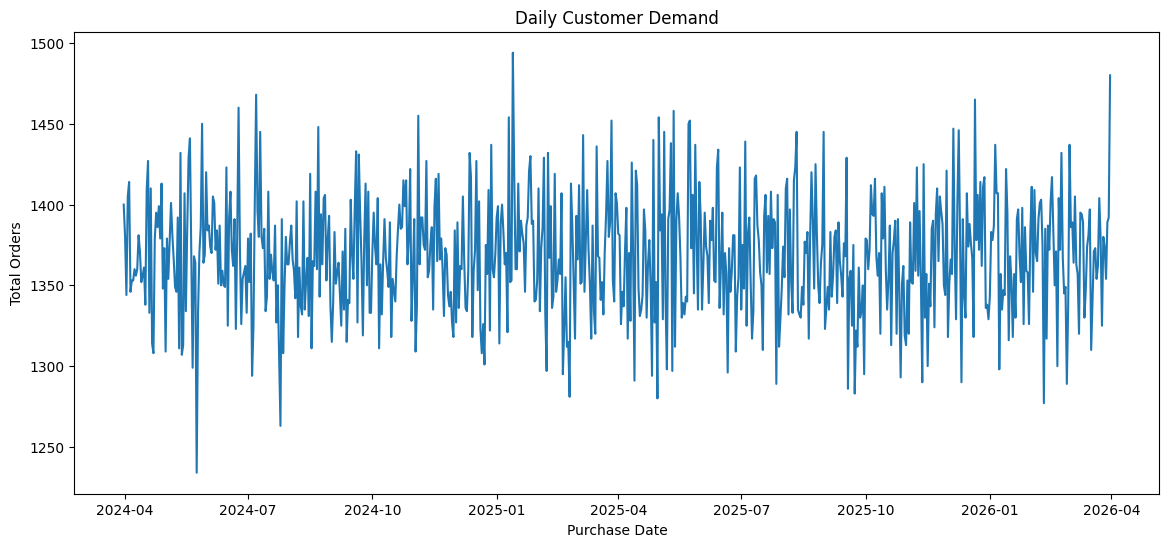

In [8]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_demand['purchase_date'],
    daily_demand['total_orders']
)

plt.title('Daily Customer Demand')
plt.xlabel('Purchase Date')
plt.ylabel('Total Orders')

plt.show()

Creating a 7-day Moving Average

In [10]:
daily_demand['7_day_MA'] = (
    daily_demand['total_orders']
    .rolling(window=7)
    .mean()
)

Graphical view of an average customer-demand trend over every 7-day Moving period. This is important to help smoothen out the noise in the daily demand trend graph

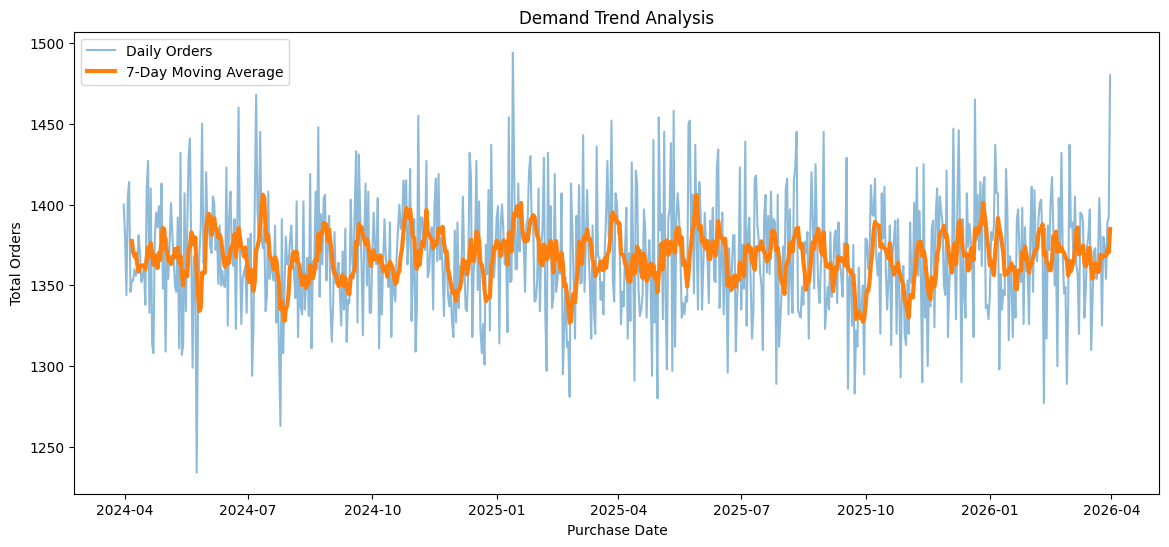

In [11]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_demand['purchase_date'],
    daily_demand['total_orders'],
    label='Daily Orders',
    alpha=0.5
)

plt.plot(
    daily_demand['purchase_date'],
    daily_demand['7_day_MA'],
    label='7-Day Moving Average',
    linewidth=3
)

plt.title('Demand Trend Analysis')
plt.xlabel('Purchase Date')
plt.ylabel('Total Orders')

plt.legend()

plt.show()

#### Implementing Machine Learning Model for Forecasting

For this Project I will use the Prophet Model because:
- It handles seasonality trends well
- It is widely known and approved for learning previous trends and making future predictions
- It creates good visualisations

In [12]:
prophet_df = daily_demand.rename(columns={
    'purchase_date': 'ds',
    'total_orders': 'y'
})

In [15]:
prophet_df.head(10)

,ds,y,7_day_MA
0,2024-03-31,1400,NaN
1,2024-04-01,1380,NaN
2,2024-04-02,1344,NaN
3,2024-04-03,1405,NaN
4,2024-04-04,1414,NaN
5,2024-04-05,1346,NaN
6,2024-04-06,1353,1377.428571
7,2024-04-07,1353,1370.714286
8,2024-04-08,1360,1367.857143
9,2024-04-09,1356,1369.571429


##### Training Prophet Model with historical data of the past 2 years and later test the Model's forecasting accuracy using an unseen part of the same data

For this, we will divide our daily demand dataset into:
- Training/ Teaching - using 80% of the dataset
- Testing - using 20% of the dataset

In [17]:
train_size = int(len(prophet_df) * 0.8)

train = prophet_df[:train_size]
test = prophet_df[train_size:]

Data from 584 days will be used to train the Model and data from unseen 147 days will be used to test the models predictive accuracy (Totaling 731 days- approximately 2 years of daily orders)

In [18]:
print(train.shape)
print(test.shape)

(584, 3)
(147, 3)


Initializing & Training Model

In [19]:
model = Prophet()

In [20]:
model.fit(train)

20:35:00 - cmdstanpy - INFO - Chain [1] start processing
20:35:03 - cmdstanpy - INFO - Chain [1] done processing


Generate Future Periods for forecasting

In [21]:
future = model.make_future_dataframe(
    periods=len(test),
    freq='D'
)

In [22]:
forecast = model.predict(future)

Viewing the Model's Forecast

- ds            - Purchase date
- yhat	        - predicted demand
- yhat_lower	- lower prediction bound
- yhat_upper	- upper prediction bound

In [25]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
726,2026-03-27,1342.008898,1293.120540,1389.060094
727,2026-03-28,1346.547213,1300.060599,1398.516845
728,2026-03-29,1347.272260,1300.732669,1393.822629
729,2026-03-30,1353.113240,1307.039840,1397.737681
730,2026-03-31,1341.871379,1295.526122,1390.350413


Such Forecast ranges helps the company prepare for:

- Inventory planning
- Labour scheduling
- demand spikes
- operational/demand variability
- Transport coordination

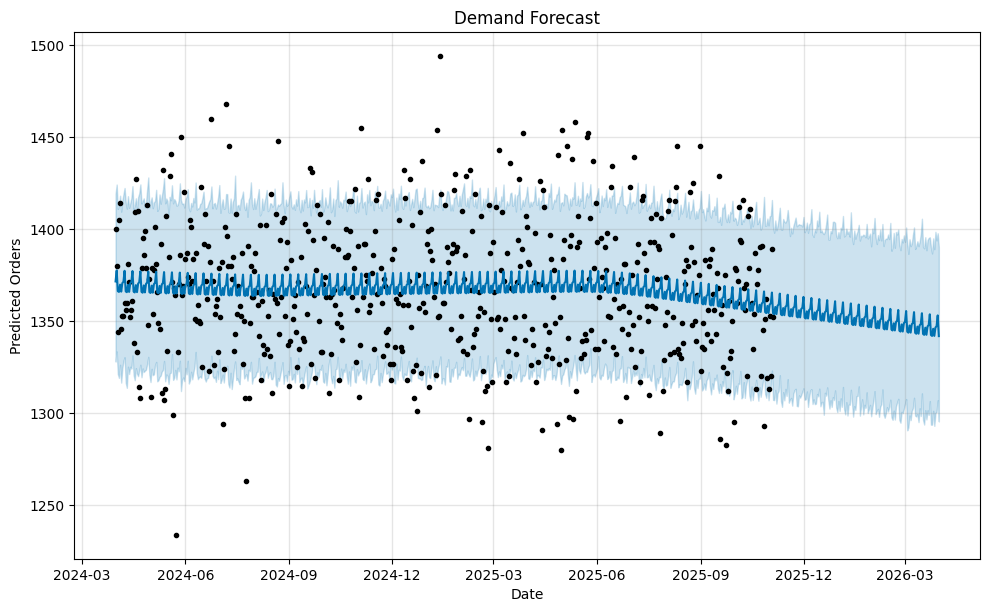

In [27]:
forecast_plot = model.plot(forecast)

plt.title('Demand Forecast')
plt.xlabel('Date')
plt.ylabel('Predicted Orders')

plt.show()

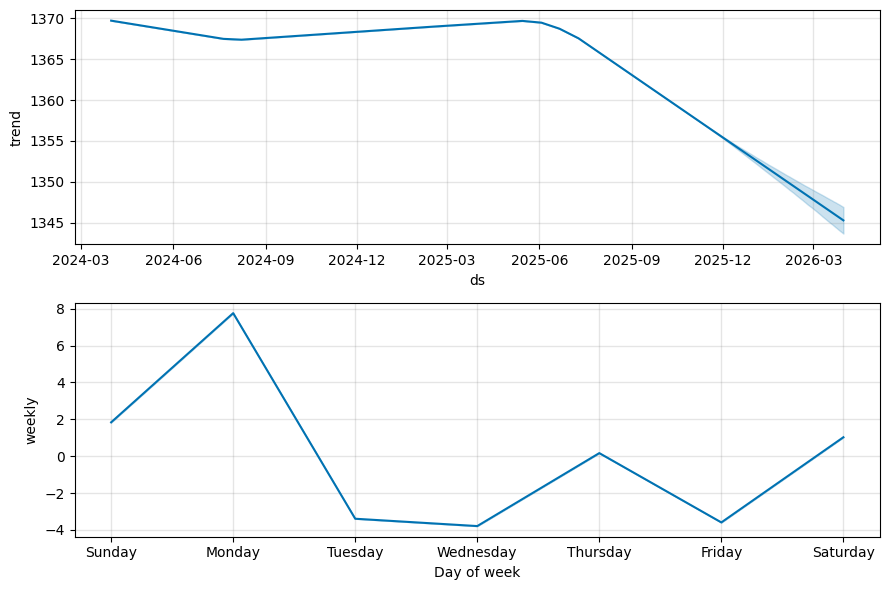

In [28]:
model.plot_components(forecast)

plt.show()

### Forecast Evaluation

In [29]:
predictions = forecast[['ds', 'yhat']].tail(len(test))

Calculating Mean Absolute Error (Used to measure average forecasting error)

- The Lower it is, the more reliable the forecast is

In [30]:
mae = mean_absolute_error(
    test['y'],
    predictions['yhat']
)

print(f"MAE: {mae:.2f}")

MAE: 33.49


Calculating RMSE- Measures forecasting error while penalizing large mistakes more heavily

In [31]:
rmse = np.sqrt(
    mean_squared_error(
        test['y'],
        predictions['yhat']
    )
)

print(f"RMSE: {rmse:.2f}")

RMSE: 41.08


Visualisation of Actual Demand Trend vs Predicted Demand Trend

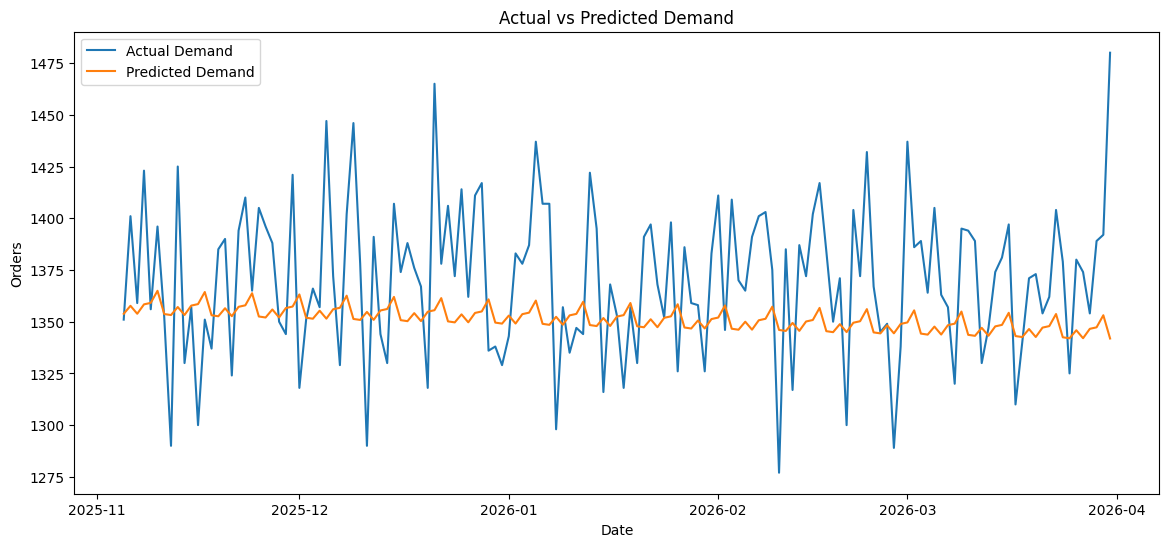

In [32]:
plt.figure(figsize=(14,6))

plt.plot(
    test['ds'],
    test['y'],
    label='Actual Demand'
)

plt.plot(
    predictions['ds'],
    predictions['yhat'],
    label='Predicted Demand'
)

plt.title('Actual vs Predicted Demand')
plt.xlabel('Date')
plt.ylabel('Orders')

plt.legend()

plt.show()

# Operational Insights

## Key Findings

- Demand forecasting reveals recurring purchasing patterns over time.
- Forecasted demand variability highlights the importance of flexible inventory planning.
- Accurate forecasting supports proactive supply chain decision-making.

## Supply Chain Implications

Demand forecasting can support:
- inventory optimization
- warehouse resource allocation
- supplier coordination
- transportation planning
- stockout prevention

## Recommendations

- Increase safety stock before forecasted demand peaks.
- Improve forecasting refresh frequency during volatile demand periods.
- Integrate forecasting outputs into inventory replenishment planning.